# HW4 Solutions

C1 = 0.08571429,  C2 = 0.01428571
A  = 0.03153732, B = -0.01132538


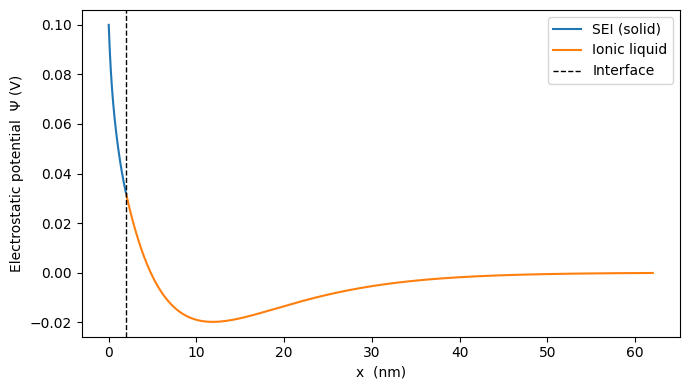

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Psi0 = 0.1           # V
Psi0p = -0.1         # V / nm
ld_il = 10.0         # ionic-liquid Debye length, nm
lc = ld_il / 2.0     # correlation length, nm
ld_s = 2.0           # solid Debye length, nm
lsp = 0.5            # lattice spacing, nm
ls = 2.0             # SEI thickness, nm
sqrt2 = np.sqrt(2.0)

def Psi_s(x, C1, C2):
    return C1 * np.exp(-x / ld_s) + C2 * np.exp(-2 * x / lsp)

def dPsi_s(x, C1, C2):
    return -(C1 / ld_s) * np.exp(-x / ld_s) - (2 * C2 / lsp) * np.exp(-2 * x / lsp)

def Psi_il(x, A, B):
    xi = x - ls
    return (A + B * xi) * np.exp(-sqrt2 * xi / ld_il)

def dPsi_il(x, A, B):
    xi = x - ls
    a = sqrt2 / ld_il
    return (B - a * (A + B * xi)) * np.exp(-a * xi)

def d3Psi_il(x, A, B):
    xi = x - ls
    a = sqrt2 / ld_il
    return (3 * a**2 * B - a**3 * (A + B * xi)) * np.exp(-a * xi)

# -------------------------------------------------------------
# 1.  Solve for C1, C2 from metal/SEI boundary
# -------------------------------------------------------------
A_mat = np.array([[1.0, 1.0], [-1.0 / ld_s, -2.0 / lsp]])
b_vec = np.array([Psi0, Psi0p])
C1, C2 = np.linalg.solve(A_mat, b_vec)

# -------------------------------------------------------------
# 2.  Continuity of potential at x = ls → find A
# -------------------------------------------------------------
A_const = Psi_s(ls, C1, C2)

# -------------------------------------------------------------
# 3.  Differentiability of potential at x = ls → find B
# -------------------------------------------------------------
lhs = dPsi_s(ls, C1, C2)
a = sqrt2 / ld_il
B_const_2 = (lhs + A_const * a)

print(f"C1 = {C1:.8f},  C2 = {C2:.8f}")
print(f"A  = {A_const:.8f}, B = {B_const_2:.8f}")

x_solid = np.linspace(0.0, ls, 200)
x_liquid = np.linspace(ls, ls + 60.0, 600)

psi_s_vals = Psi_s(x_solid, C1, C2)
psi_li_vals = Psi_il(x_liquid, A_const, B_const_2)

plt.figure(figsize=(7, 4))
plt.plot(x_solid, psi_s_vals, label="SEI (solid)")
plt.plot(x_liquid, psi_li_vals, label="Ionic liquid")
plt.axvline(ls, color="k", linestyle="--", linewidth=1, label="Interface")
plt.xlabel("x  (nm)")
plt.ylabel("Electrostatic potential  Ψ (V)")
plt.legend()
plt.tight_layout()
plt.savefig("./potential2.pdf")
plt.show()
